# 🚀 Soft Margin Support Vector Machine (SVM) In-Depth Guide

## 1. 📐 Intuition and Working of Soft Margin SVM

**The Problem with Hard Margin:**
Imagine you have a group of red circles and blue squares that you want to separate with a line. A Hard Margin SVM demands a perfect split with absolutely no data points inside the margin. 
However, real-world data is almost never perfect. What if one red circle is accidentally mixed in with the blue squares? 
- A Hard Margin SVM would either fail to find any line at all, or it would draw a severely distorted, narrow boundary just to accommodate that single outlier. This is called **"overfitting."**

**The Soft Margin Solution:**
A Soft Margin SVM accepts that data is messy. It says, *"I want the widest street (margin) possible, but I will allow a few cars (data points) to drive on the sidewalk or even on the wrong side of the street if it helps the overall street be wider and straighter."*

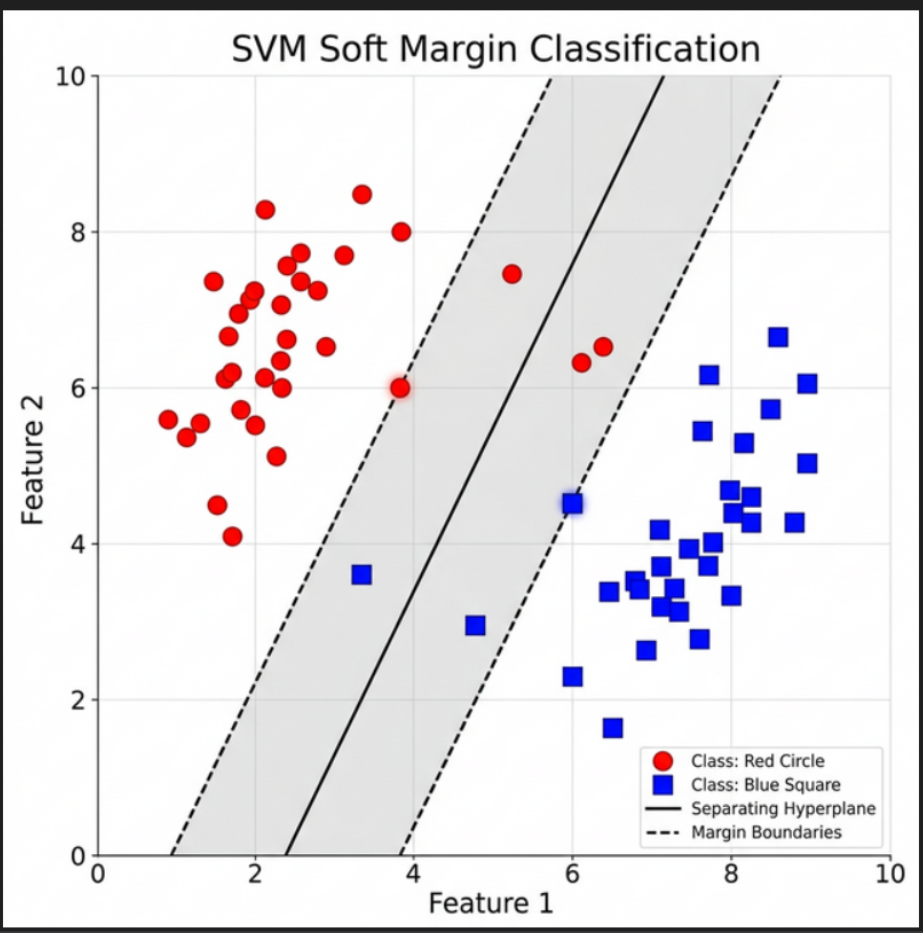

It does this by introducing a concept called a **"Slack Variable"**. For every single data point, the model calculates a slack value. 
- If the point is safely outside the margin on the correct side, its slack is `0`. 
- If the point is inside the margin or on the totally wrong side of the line, its slack is greater than `0`.

The SVM now has two competing goals:
1. Make the margin as wide as possible.
2. Keep the sum of all the errors (the slack) as small as possible.

To balance these two goals, we use a hyperparameter called **`C`**.
- **High `C`:** The model is very strict. It heavily penalizes errors, leading to a narrower margin but fewer misclassifications (acts more like a Hard Margin).
- **Low `C`:** The model is very relaxed. It allows more errors in order to draw a wider, more general margin.

## 2. 🧮 The Mathematics of Soft Margin SVM (Simplified)

Let's break down the math into simple, intuitive concepts rather than using complex formulas. 

### Step 1: The Equation of the Line
In SVM, our main goal is to find a straight line to separate our data. Any straight line can be written as:
**`w * x + b = 0`**

- **`x`**: This is your data point (like a person's Age and Income).
- **`w`**: These are the "weights". They determine the angle or tilt of the line.
- **`b`**: This is the "bias" (or intercept). It shifts the line up, down, left, or right.

### Step 2: The Margins (The Sidewalks)
If `w * x + b = 0` is the exact middle of the street, then the edges of the street (the margins) are:
- Positive edge: **`w * x + b = 1`**
- Negative edge: **`w * x + b = -1`**

In a **Hard Margin**, the strict computer logic is that EVERY single data point must be correctly classified AND outside these `1` and `-1` boundaries. No exceptions are allowed.

### Step 3: Giving the Math some "Slack"
Because real data is messy, a **Soft Margin** allows exceptions by introducing a concept called a **Slack Variable**. 
Let's just call it the `Error_Allowance`.

The new Soft Margin rule becomes:
*"The data point must be outside the boundary... **minus its own personal Error Allowance**."*

What the `Error_Allowance` means for a specific data point:
- **If Allowance = 0:** The point is perfectly safe. It's correctly classified and far away from the line.
- **If Allowance is between 0 and 1:** The point is technically correct, but it's stuck inside the margin (it stepped on the sidewalk).
- **If Allowance is > 1:** The point is officially misclassified (it crossed the middle of the street).

### Step 4: The Final Goal (The Objective Function)

The SVM algorithm now has two competing jobs that it must balance:
1. **Job 1:** Make the street (the margin) as wide as possible.
2. **Job 2:** Keep the sum of all the `Error_Allowances` as close to zero as possible.

To tell the computer which job is more important, we use a single number: **`C`** (The Penalty Parameter). 

The final mathematical goal the computer solves is this equation:
**Minimize this total score:**   `[ Math that makes the street wider ]   +   [ C * (Sum of all Error Allowances) ]`

### How `C` controls the model:
- **If you set `C` really high (e.g., 10,000):** 
  The second half of that equation becomes massive if there are any errors. The computer gets terrified of errors, so it forces the allowances to be 0. *This acts just like a Hard Margin.*

- **If you set `C` really low (e.g., 0.01):** 
  The penalty part becomes tiny. The computer stops caring about individual errors and focuses all its energy entirely on Job 1: making the street as wide as possible.

## The Mathematics of Soft Margin SVM

### 1. The Decision Boundary (Hyperplane)
In an $n$-dimensional space, the separating hyperplane is defined by the equation:
$$ w^T x + b = 0 $$
where:
*   $\mathbf{w}$ is the weight vector (normal to the hyperplane).
*   $\mathbf{x}$ is the feature vector of a data point.
*   $\mathbf{b}$ is the bias term.

The two margin boundaries (the edges of the "street") are defined as:
*   Positive boundary: $w^T x + b = 1$
*   Negative boundary: $w^T x + b = -1$


### 2. The Slack Variable ($\zeta$)
In a Hard Margin SVM, the strict constraint for correctly classifying a point $x_i$ with label $y_i \in \{-1, 1\}$ is $y_i (w^T x_i + b) \geq 1$.

To create a **Soft Margin**, we introduce a slack variable **$\zeta_i \geq 0$** for each data point. This allows some points to violate the strict margin constraint. The new constraint becomes:
$$ y_i (w^T x_i + b) \geq 1 - \zeta_i $$

**Interpretation of $\zeta_i$:**
*   $\zeta_i = 0$: The point is correctly classified and lies outside or exactly on the correct margin.
*   $0 < \zeta_i < 1$: The point is correctly classified but is located inside the margin boundaries.
*   $\zeta_i \geq 1$: The point is misclassified (it is on the wrong side of the separating hyperplane).


### 3. The Objective Function
The goal of SVM is two-fold:
1.  **Maximize the margin width:** The total width of the margin is $\frac{2}{||w||}$. Maximizing this is mathematically equivalent to minimizing $\frac{1}{2} ||w||^2$.
2.  **Minimize the classification errors:** We want to keep the sum of the slack variables $\sum_{i=1}^n \zeta_i$ as small as possible.

We balance these two goals using a regularization hyperparameter, **$C$**. 

**The Primal Optimization Problem for Soft Margin SVM is:**

$$ \min_{w, b, \zeta} \left( \frac{1}{2} ||w||^2 + C \sum_{i=1}^n \zeta_i \right) $$

**Subject to the constraints:**
$$ y_i (w^T x_i + b) \geq 1 - \zeta_i \quad \text{for } i = 1, \dots, n $$
$$ \zeta_i \geq 0 \quad \text{for } i = 1, \dots, n $$

### 4. The Role of Hyperparameter $C$
*   **Large $C$ (e.g., $C \to \infty$):** The penalty for misclassification is very high. The model forces $\zeta_i \to 0$, leading to a narrower margin and behaving like a **Hard Margin** SVM. Risk of overfitting.
*   **Small $C$:** The penalty for misclassification is low. The model accepts more margin violations (larger $\zeta_i$) in exchange for a wider, more generalizable margin. Risk of underfitting.
